# Precision Cardiotoxicity Prediction: A Machine Learning Framework for hERG Inhibition 🔬

## 👤 Author
**Pritom Kundu**
**B Pharm (Honors) | University of Rajshahi**

---

## 📝 Project Overview
This project delineates the development of a sophisticated machine learning framework designed for the **precise prediction of hERG channel (ChEMBL ID 240) cardiotoxicity**, a *critical and complex safety concern* in modern pharmaceutical development.

Cardiotoxicity, particularly hERG channel inhibition, poses a significant hurdle in drug discovery, often resulting in late-stage attrition or post-market withdrawals. This work directly addresses this challenge by employing advanced computational strategies to enhance drug safety assessment at earlier stages.

Our primary objectives are multifaceted:
*   🎯 **To significantly enhance the efficiency and accuracy of early-stage drug screening protocols** by providing robust predictive models.
*   🧪 **To strategically leverage comprehensive cheminformatics datasets and state-of-the-art computational techniques** to extract meaningful insights.
*   🚀 **To contribute to the mitigation of adverse cardiac event risks and accelerate the development of safer therapeutic agents** for patient benefit.

The proposed framework systematically integrates a series of key methodological steps, including **rigorous data preprocessing**, **advanced feature engineering methodologies**, **judicious selection of machine learning models**, and **comprehensive validation strategies**. This holistic approach is meticulously designed to ensure both *superior predictive performance and broad generalizability* across diverse chemical spaces.

Ultimately, this research aims to provide a reliable computational tool to guide medicinal chemistry efforts, fostering the development of drug candidates with optimized safety profiles.

## **Step 01: Environment Setup and Dependency Installation** 🛠️

This crucial initial phase involves the systematic installation of essential libraries required for the successful execution of our machine learning framework. Specifically, we will focus on integrating **RDKit** 🧬 and **`chembl_webresource_client`** 🌐, both of which are indispensable for cheminformatics operations, molecular manipulation, and efficient interaction with the ChEMBL database, respectively.

In [1]:
# 01 Installation of needed packages
%%capture
!pip install rdkit
!pip install chembl_webresource_client

## **Step 02: Importing Necessary Libraries** 📦⚙️
This section is dedicated to the essential task of importing all requisite Python libraries. These packages are crucial for facilitating various operations throughout the project, encompassing data manipulation, cheminformatics tasks, machine learning model development, and data visualization. Proper initialization of these dependencies ensures a seamless workflow and robust execution of the analytical framework.

In [33]:
# 01 Import needed Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## **Step 03: Mounting Google Drive for Data Access** ☁️📂

This crucial step involves securely mounting Google Drive, enabling seamless access to external datasets and ensuring persistent storage of project artifacts. This integration facilitates efficient data management and collaboration within the Colab environment.

In [3]:
# 01 Google drive mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Step 04: Creating Needed Directories** 📁✨

This crucial step involves the programmatic creation of designated directories, specifically `External_Dataset`, `Output`, and `model`. These directories are fundamental for organizing and persisting project-related assets, including raw data, processed outputs, and trained machine learning models, thereby ensuring a structured and reproducible workflow.

In [4]:
# 01 Create Directory : External_Dataset
dir_name = "/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/External_Dataset"
os.makedirs(dir_name, exist_ok=True)

In [5]:
# 02 Create Directory : Output
dir_name = "/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Output"
os.makedirs(dir_name, exist_ok=True)

In [6]:
# 03 Create Directory : Model
dir_name = "/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Model"
os.makedirs(dir_name, exist_ok=True)

## **Step 05: Target Identification and Data Collection Strategy** 🎯📊

This pivotal step focuses on precisely identifying the appropriate biological target—specifically, the hERG channel (ChEMBL ID 240)—and subsequently formulating a robust strategy for comprehensive data collection. This involves leveraging cheminformatics resources to retrieve relevant experimental data, which is essential for the development and validation of our predictive machine learning models.

In [7]:
# 01 Importing new client from chembl_webresource_client
from chembl_webresource_client.new_client import new_client

In [ ]:
# 02 Building the target query
target = new_client.target
target

In [ ]:
# 03 Setting up the target query
target_query = target.search("hERG")

In [ ]:
# 04 Checking Target Query Type
type(target_query)

chembl_webresource_client.query_set.QuerySet

In [ ]:
# 05 Creating Data frame with targets
targets = pd.DataFrame.from_dict(target_query)
targets

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,13.0,False,CHEMBL240,"[{'accession': 'Q12809', 'component_descriptio...",SINGLE PROTEIN,9606
1,[],Homo sapiens,Melanin-concentrating hormone receptor 2/HERG,12.0,False,CHEMBL4106188,"[{'accession': 'Q12809', 'component_descriptio...",SELECTIVITY GROUP,9606
2,[],Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9.0,False,CHEMBL2363011,"[{'accession': 'Q9H252', 'component_descriptio...",SINGLE PROTEIN,9606
3,[],Homo sapiens,Voltage-gated potassium channel,2.0,False,CHEMBL2362996,"[{'accession': 'P51787', 'component_descriptio...",PROTEIN FAMILY,9606


In [ ]:
# 06 Selecting the desired target
selected_target = targets.target_chembl_id[0]
selected_target

'CHEMBL240'

In [ ]:
# 07 Explore the selected CHEMBL dataset (Only Bioactivity data)
activity = new_client.activity
activity_value = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50").filter(standard_units="nM").filter(standard_relation = "=")
activity_value

[{'action_type': None, 'activity_comment': None, 'activity_id': 305156, 'activity_properties': [], 'assay_chembl_id': 'CHEMBL841079', 'assay_description': 'Inhibition of hERG currents Kv11.1', 'assay_type': 'T', 'assay_variant_accession': None, 'assay_variant_mutation': None, 'bao_endpoint': 'BAO_0000190', 'bao_format': 'BAO_0000019', 'bao_label': 'assay format', 'canonical_smiles': 'O=C1NCCN1CCN1CCC(c2cn(-c3ccc(F)cc3)c3ccc(Cl)cc23)CC1', 'data_validity_comment': None, 'data_validity_description': None, 'document_chembl_id': 'CHEMBL1134478', 'document_journal': 'J Med Chem', 'document_year': 2001, 'ligand_efficiency': None, 'molecule_chembl_id': 'CHEMBL12713', 'molecule_pref_name': 'SERTINDOLE', 'parent_molecule_chembl_id': 'CHEMBL12713', 'pchembl_value': '7.85', 'potential_duplicate': 0, 'qudt_units': 'http://www.openphacts.org/units/Nanomolar', 'record_id': 71623, 'relation': '=', 'src_id': 1, 'standard_flag': 1, 'standard_relation': '=', 'standard_text_value': None, 'standard_type': 

In [ ]:
# 08 Creating a Data frame with activity data
df_1 = pd.DataFrame.from_dict(activity_value)
df_1.head(5)

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,305156,[],CHEMBL841079,Inhibition of hERG currents Kv11.1,T,None,None,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,None,NaN,IC50,nM,UO_0000065,None,14.0
1,None,None,305244,[],CHEMBL691014,K+ channel blocking activity in human embryoni...,F,None,None,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,None,NaN,IC50,nM,UO_0000065,None,32.2
2,None,None,305245,[],CHEMBL691013,K+ channel blocking activity in human embryoni...,F,None,None,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,None,NaN,IC50,nM,UO_0000065,None,5950.0
3,None,None,306561,[],CHEMBL691014,K+ channel blocking activity in human embryoni...,F,None,None,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,None,NaN,IC50,nM,UO_0000065,None,143.0
4,None,None,306562,[],CHEMBL877203,K+ channel blocking activity in Chinese hamste...,F,None,None,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,None,NaN,IC50,nM,UO_0000065,None,196.0


In [ ]:
# 09 Checking the data frame
df_1.shape

(11712, 46)

In [ ]:
# 10 Index Reset
df_1 = df_1.reset_index(drop=True, inplace=True)
df_1

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,305156,[],CHEMBL841079,Inhibition of hERG currents Kv11.1,T,None,None,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,None,NaN,IC50,nM,UO_0000065,None,14.0
1,None,None,305244,[],CHEMBL691014,K+ channel blocking activity in human embryoni...,F,None,None,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,None,NaN,IC50,nM,UO_0000065,None,32.2
2,None,None,305245,[],CHEMBL691013,K+ channel blocking activity in human embryoni...,F,None,None,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,None,NaN,IC50,nM,UO_0000065,None,5950.0
3,None,None,306561,[],CHEMBL691014,K+ channel blocking activity in human embryoni...,F,None,None,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,None,NaN,IC50,nM,UO_0000065,None,143.0
4,None,None,306562,[],CHEMBL877203,K+ channel blocking activity in Chinese hamste...,F,None,None,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,None,NaN,IC50,nM,UO_0000065,None,196.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11707,None,1273888,28990994,[],CHEMBL5739235,ERG Channel Binding Assay: Fluorescence polari...,B,None,None,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,None,NaN,IC50,nM,UO_0000065,None,5500.0
11708,None,1275125,28994426,[],CHEMBL5739275,hERG assay: The inhibition of activity of hERG...,B,None,None,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,None,NaN,IC50,nM,UO_0000065,None,4300.0
11709,None,1275128,28994435,[],CHEMBL5739275,hERG assay: The inhibition of activity of hERG...,B,None,None,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,None,NaN,IC50,nM,UO_0000065,None,34600.0
11710,None,1275129,28994438,[],CHEMBL5739275,hERG assay: The inhibition of activity of hERG...,B,None,None,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,None,NaN,IC50,nM,UO_0000065,None,55800.0


In [ ]:
# 11 Saving Final Data set
df_1.to_csv("/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Output/01_hERG_bioactivity_data.csv", index=False)

## **Step 06: Data Preprocessing and Cleaning** 🧹📊

This critical stage focuses on refining the raw bioactivity data to ensure its quality, reliability, and suitability for subsequent machine learning model development. Comprehensive data preprocessing is paramount for mitigating potential biases and enhancing the predictive performance of the models.

Specifically, this step involves the following key operations:

*   **Handling Missing Values** 🩹: Systematically identifying and addressing any missing data points within the dataset to maintain data integrity.
*   **Removing Duplicates** 🔄: Eliminating redundant entries to prevent overfitting and ensure the uniqueness of each data record.
*   **Saving Cleaned Data** 💾: Persisting the refined dataset, ready for feature engineering and model training, thereby ensuring reproducibility and traceability.

In [ ]:
# 01 Reading The last saved File (df_1)
df_2 = pd.read_csv("/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Output/01_hERG_bioactivity_data.csv")
df_2

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,NaN,NaN,305156,[],CHEMBL841079,Inhibition of hERG currents Kv11.1,T,NaN,NaN,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,14.0
1,NaN,NaN,305244,[],CHEMBL691014,K+ channel blocking activity in human embryoni...,F,NaN,NaN,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,32.2
2,NaN,NaN,305245,[],CHEMBL691013,K+ channel blocking activity in human embryoni...,F,NaN,NaN,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,5950.0
3,NaN,NaN,306561,[],CHEMBL691014,K+ channel blocking activity in human embryoni...,F,NaN,NaN,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,143.0
4,NaN,NaN,306562,[],CHEMBL877203,K+ channel blocking activity in Chinese hamste...,F,NaN,NaN,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,196.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11707,NaN,1273888.0,28990994,[],CHEMBL5739235,ERG Channel Binding Assay: Fluorescence polari...,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,5500.0
11708,NaN,1275125.0,28994426,[],CHEMBL5739275,hERG assay: The inhibition of activity of hERG...,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,4300.0
11709,NaN,1275128.0,28994435,[],CHEMBL5739275,hERG assay: The inhibition of activity of hERG...,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,34600.0
11710,NaN,1275129.0,28994438,[],CHEMBL5739275,hERG assay: The inhibition of activity of hERG...,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Voltage-gated inwardly rectifying potassium ch...,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,55800.0


In [ ]:
# 02 Exploring the missing data
df_2.isnull().sum()

,0
action_type,9810
activity_comment,10100
activity_id,0
activity_properties,0
assay_chembl_id,0
assay_description,0
assay_type,0
assay_variant_accession,11689
assay_variant_mutation,11689
bao_endpoint,0


In [ ]:
# 03 Removing the missing values from (standard_value) Column
df_2 = df_1[df_1.standard_value.notna()]
df_2.standard_value.isnull().sum()

np.int64(0)

In [ ]:
# 04 Removing missing values from (canonical smiles) column
df_2 = df_2[df_2.canonical_smiles.notna()]
df_2.canonical_smiles.isnull().sum()

np.int64(0)

In [ ]:
# 05 Removing duplicated SMILES
df_2 = df_2.drop_duplicates(['canonical_smiles'])
df_2.shape

(9547, 46)

In [ ]:
# 06 Ovserving the unique SMILES in canonical_smiles collumn
unique_smiles = len(df_2.canonical_smiles.unique())
unique_smiles == len(df_2.canonical_smiles)

True

In [ ]:
# 07 Curation of the preprocessed data with needed collumn
needed_collumn = ['molecule_chembl_id','canonical_smiles','standard_value']
df_3 = df_2[needed_collumn].reset_index(drop=True)
df_3

,molecule_chembl_id,canonical_smiles,standard_value
0,CHEMBL12713,O=C1NCCN1CCN1CCC(c2cn(-c3ccc(F)cc3)c3ccc(Cl)cc...,14.0
1,CHEMBL1108,O=C(CCCN1CC=C(n2c(=O)[nH]c3ccccc32)CC1)c1ccc(F...,32.2
2,CHEMBL2368925,O=C(O[C@@H]1C[C@@H]2C[C@H]3C[C@H](C1)N2CC3=O)c...,5950.0
3,CHEMBL6966,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C...,143.0
4,CHEMBL1107,CCCCN(CCCC)CCC(O)c1cc2c(Cl)cc(Cl)cc2c2cc(C(F)(...,196.0
...,...,...,...
9542,CHEMBL4218821,Nc1nc(N2CCC(N3C[C@@H]4CCCN4C[C@@H]3Cc3ccc(Cl)c...,5500.0
9543,CHEMBL5964913,CCC(C)C(NC(=O)C(Cc1ccccc1)NC(=O)C(CC(C)C)NC(=O...,4300.0
9544,CHEMBL5797561,N#Cc1ccc(COc2cccc(C3CCN(Cc4nc5ccc(C(=O)O)nc5n4...,34600.0
9545,CHEMBL5899541,C[C@H]1CN(c2cncc(OCc3ccc(C#N)cc3F)n2)CCN1Cc1nc...,55800.0


In [ ]:
# 08 Exporting The file (df_3)
df_3.to_csv("/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Output/02_hERG_bioactivity_data_curated.csv", index=False)

## **Step 07** Data Compound Labaling
Here we will label the compound according to the standard_value
- Active Compound: standard value <= 1000
- Inactive Compound: standard value >= 10000
- Intermidiate Compound:standard value 1001 - 10000

## **Step 07: Data Compound Labeling and Categorization** 🏷️📊

This crucial step involves the classification of compounds based on their bioactivity values, specifically the `standard_value` (IC50 in nM). Proper categorization of compounds into 'Active', 'Inactive', and 'Intermediate' classes is fundamental for the development of robust machine learning models in drug discovery. This process allows for a clear distinction between compounds exhibiting significant biological activity and those with minimal or no effect, thereby facilitating the training of predictive models.

Specifically, compounds will be categorized according to the following thresholds:

*   **Active Compound** 🟢: Compounds with `standard_value` less than or equal to 1000 nM.
*   **Intermediate Compound** 🟡: Compounds with `standard_value` ranging from 1001 nM to 9999 nM.
*   **Inactive Compound** 🔴: Compounds with `standard_value` greater than or equal to 10000 nM.

This categorization strategy aligns with established practices in cheminformatics for classifying drug-like molecules based on their potency, enabling a more nuanced understanding of their pharmacological profiles.

In [ ]:
# 01 Reading the last saved file (df_3)
df_4 = pd.read_csv("/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Output/02_hERG_bioactivity_data_curated.csv")
df_4

,molecule_chembl_id,canonical_smiles,standard_value
0,CHEMBL12713,O=C1NCCN1CCN1CCC(c2cn(-c3ccc(F)cc3)c3ccc(Cl)cc...,14.0
1,CHEMBL1108,O=C(CCCN1CC=C(n2c(=O)[nH]c3ccccc32)CC1)c1ccc(F...,32.2
2,CHEMBL2368925,O=C(O[C@@H]1C[C@@H]2C[C@H]3C[C@H](C1)N2CC3=O)c...,5950.0
3,CHEMBL6966,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C...,143.0
4,CHEMBL1107,CCCCN(CCCC)CCC(O)c1cc2c(Cl)cc(Cl)cc2c2cc(C(F)(...,196.0
...,...,...,...
9542,CHEMBL4218821,Nc1nc(N2CCC(N3C[C@@H]4CCCN4C[C@@H]3Cc3ccc(Cl)c...,5500.0
9543,CHEMBL5964913,CCC(C)C(NC(=O)C(Cc1ccccc1)NC(=O)C(CC(C)C)NC(=O...,4300.0
9544,CHEMBL5797561,N#Cc1ccc(COc2cccc(C3CCN(Cc4nc5ccc(C(=O)O)nc5n4...,34600.0
9545,CHEMBL5899541,C[C@H]1CN(c2cncc(OCc3ccc(C#N)cc3F)n2)CCN1Cc1nc...,55800.0


In [ ]:
# 02 Applying the codition to label the Compound
bioactivity_class = []
for i in df_4.standard_value:
  if float(i) <= 1000:
    bioactivity_class.append("active")
  elif float(i) >= 10000:
    bioactivity_class.append("inactive")
  else:
    bioactivity_class.append("intermediate")

In [ ]:
# 03 Converting List to Data Frame
bioactivity_class = pd.Series(bioactivity_class, name='bioactivity_class')
bioactivity_class

,bioactivity_class
0,active
1,active
2,intermediate
3,active
4,active
...,...
9542,intermediate
9543,intermediate
9544,inactive
9545,inactive


In [ ]:
# 04 Concating Data frames
df_5 = pd.concat([df_4, bioactivity_class], axis=1)
df_5

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL12713,O=C1NCCN1CCN1CCC(c2cn(-c3ccc(F)cc3)c3ccc(Cl)cc...,14.0,active
1,CHEMBL1108,O=C(CCCN1CC=C(n2c(=O)[nH]c3ccccc32)CC1)c1ccc(F...,32.2,active
2,CHEMBL2368925,O=C(O[C@@H]1C[C@@H]2C[C@H]3C[C@H](C1)N2CC3=O)c...,5950.0,intermediate
3,CHEMBL6966,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C...,143.0,active
4,CHEMBL1107,CCCCN(CCCC)CCC(O)c1cc2c(Cl)cc(Cl)cc2c2cc(C(F)(...,196.0,active
...,...,...,...,...
9542,CHEMBL4218821,Nc1nc(N2CCC(N3C[C@@H]4CCCN4C[C@@H]3Cc3ccc(Cl)c...,5500.0,intermediate
9543,CHEMBL5964913,CCC(C)C(NC(=O)C(Cc1ccccc1)NC(=O)C(CC(C)C)NC(=O...,4300.0,intermediate
9544,CHEMBL5797561,N#Cc1ccc(COc2cccc(C3CCN(Cc4nc5ccc(C(=O)O)nc5n4...,34600.0,inactive
9545,CHEMBL5899541,C[C@H]1CN(c2cncc(OCc3ccc(C#N)cc3F)n2)CCN1Cc1nc...,55800.0,inactive


In [ ]:
# 05 Removing the intermidiate class from (df_5)
df_6 = df_5[df_5.bioactivity_class != "intermediate"]
df_6.reset_index(drop=True, inplace=True)
df_6

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL12713,O=C1NCCN1CCN1CCC(c2cn(-c3ccc(F)cc3)c3ccc(Cl)cc...,14.0,active
1,CHEMBL1108,O=C(CCCN1CC=C(n2c(=O)[nH]c3ccccc32)CC1)c1ccc(F...,32.2,active
2,CHEMBL6966,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C...,143.0,active
3,CHEMBL1107,CCCCN(CCCC)CCC(O)c1cc2c(Cl)cc(Cl)cc2c2cc(C(F)(...,196.0,active
4,CHEMBL998,CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc3cccnc32)CC1,173.0,active
...,...,...,...,...
5274,CHEMBL5918018,Nc1nnc(N2CCC(N3C[C@@H]4CC(F)(F)CN4C[C@@H]3Cc3c...,17500.0,inactive
5275,CHEMBL5746607,COC(C)(C)[C@H]1CN(C2CCN(c3nnc(N)[nH]3)CC2)[C@@...,17500.0,inactive
5276,CHEMBL5797561,N#Cc1ccc(COc2cccc(C3CCN(Cc4nc5ccc(C(=O)O)nc5n4...,34600.0,inactive
5277,CHEMBL5899541,C[C@H]1CN(c2cncc(OCc3ccc(C#N)cc3F)n2)CCN1Cc1nc...,55800.0,inactive


In [8]:
# 06 Export the final data set (df_6)
df_7 = df_6.to_csv("/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Output/03_hERG_bioactivity_data_curated_Labeled.csv", index=False)

NameError: name 'df_6' is not defined

## **Step 08: Encoding Bioactivity Classes** 🔢

This crucial step involves transforming the categorical bioactivity classes ('Active' and 'Inactive') into numerical representations suitable for machine learning models. Encoding these classes is a fundamental preprocessing step that allows algorithms to interpret and learn from the data effectively. For binary classification tasks, a common practice is to assign integer values to each category.

Specifically, the bioactivity classes will be encoded as follows:

*   **Active compounds** 🟢 will be represented by **1**.
*   **Inactive compounds** 🔴 will be represented by **0**.

This binary encoding creates a target variable that is directly compatible with a wide range of classification algorithms, facilitating the training and evaluation of our predictive models. The `intermediate` class compounds were previously removed to focus on a clear binary classification problem.

In [ ]:
# 01 Encoding the bioactivity_class column
df_8 = df_6.copy()
df_8['bioactivity_class'] = df_8['bioactivity_class'].map({'active': 1, 'inactive': 0})
df_8

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL12713,O=C1NCCN1CCN1CCC(c2cn(-c3ccc(F)cc3)c3ccc(Cl)cc...,14.0,1
1,CHEMBL1108,O=C(CCCN1CC=C(n2c(=O)[nH]c3ccccc32)CC1)c1ccc(F...,32.2,1
2,CHEMBL6966,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C...,143.0,1
3,CHEMBL1107,CCCCN(CCCC)CCC(O)c1cc2c(Cl)cc(Cl)cc2c2cc(C(F)(...,196.0,1
4,CHEMBL998,CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc3cccnc32)CC1,173.0,1
...,...,...,...,...
5274,CHEMBL5918018,Nc1nnc(N2CCC(N3C[C@@H]4CC(F)(F)CN4C[C@@H]3Cc3c...,17500.0,0
5275,CHEMBL5746607,COC(C)(C)[C@H]1CN(C2CCN(c3nnc(N)[nH]3)CC2)[C@@...,17500.0,0
5276,CHEMBL5797561,N#Cc1ccc(COc2cccc(C3CCN(Cc4nc5ccc(C(=O)O)nc5n4...,34600.0,0
5277,CHEMBL5899541,C[C@H]1CN(c2cncc(OCc3ccc(C#N)cc3F)n2)CCN1Cc1nc...,55800.0,0


In [ ]:
# 02 Displaying the distribution of encoded bioactivity classes
display(df_8['bioactivity_class'].value_counts())

,count
bioactivity_class,
0,3386
1,1893


In [ ]:
# 03 Droping the collumns (molecule_chembl_id), (standard_value)
df_8 = df_8.drop(['molecule_chembl_id','standard_value'], axis=1)
df_8

,canonical_smiles,bioactivity_class
0,O=C1NCCN1CCN1CCC(c2cn(-c3ccc(F)cc3)c3ccc(Cl)cc...,1
1,O=C(CCCN1CC=C(n2c(=O)[nH]c3ccccc32)CC1)c1ccc(F...,1
2,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C...,1
3,CCCCN(CCCC)CCC(O)c1cc2c(Cl)cc(Cl)cc2c2cc(C(F)(...,1
4,CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc3cccnc32)CC1,1
...,...,...
5274,Nc1nnc(N2CCC(N3C[C@@H]4CC(F)(F)CN4C[C@@H]3Cc3c...,0
5275,COC(C)(C)[C@H]1CN(C2CCN(c3nnc(N)[nH]3)CC2)[C@@...,0
5276,N#Cc1ccc(COc2cccc(C3CCN(Cc4nc5ccc(C(=O)O)nc5n4...,0
5277,C[C@H]1CN(c2cncc(OCc3ccc(C#N)cc3F)n2)CCN1Cc1nc...,0


In [ ]:
# 04 Renaming the column names (canonical_smiles to SMILES) & (bioactivity_class to Class)
df_8 = df_8.rename(columns={'canonical_smiles': 'SMILES', 'bioactivity_class': 'Class'})
df_8

,SMILES,Class
0,O=C1NCCN1CCN1CCC(c2cn(-c3ccc(F)cc3)c3ccc(Cl)cc...,1
1,O=C(CCCN1CC=C(n2c(=O)[nH]c3ccccc32)CC1)c1ccc(F...,1
2,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C...,1
3,CCCCN(CCCC)CCC(O)c1cc2c(Cl)cc(Cl)cc2c2cc(C(F)(...,1
4,CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc3cccnc32)CC1,1
...,...,...
5274,Nc1nnc(N2CCC(N3C[C@@H]4CC(F)(F)CN4C[C@@H]3Cc3c...,0
5275,COC(C)(C)[C@H]1CN(C2CCN(c3nnc(N)[nH]3)CC2)[C@@...,0
5276,N#Cc1ccc(COc2cccc(C3CCN(Cc4nc5ccc(C(=O)O)nc5n4...,0
5277,C[C@H]1CN(c2cncc(OCc3ccc(C#N)cc3F)n2)CCN1Cc1nc...,0


In [ ]:
# 05 Exporting the final file
df_9 = df_8.to_csv("/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Output/04_hERG_bioactivity_data_curated_Labeled_Encoded.csv", index=False)

## **Step 09: Machine Learning Model Development (Classification)** 🤖📊

This pivotal phase of the project is dedicated to the development and implementation of machine learning models for the classification of hERG channel inhibitors. Leveraging the preprocessed and labeled bioactivity data, our primary objective is to build robust predictive models capable of accurately distinguishing between 'Active' and 'Inactive' compounds. This binary classification task is fundamental for accelerating drug discovery by providing an efficient in silico screening tool.

The methodology in this step will encompass:

*   **Feature Engineering** 🧬: Transforming chemical structures (SMILES) into numerical representations (molecular descriptors or fingerprints) suitable for machine learning algorithms. This often involves calculating physicochemical properties and structural features of the compounds.
*   **Data Splitting** 📊: Dividing the dataset into training, validation, and test sets to ensure unbiased model evaluation and prevent overfitting.
*   **Model Selection** 🧠: Exploring and selecting appropriate classification algorithms (e.g., Logistic Regression, Support Vector Machines, Random Forest, Gradient Boosting) based on their suitability for cheminformatics data.
*   **Model Training** 🚀: Training the chosen machine learning models on the prepared dataset.
*   **Model Evaluation** 📈: Assessing the performance of the trained models using relevant metrics such as accuracy, precision, recall, F1-score, and ROC-AUC, to determine their predictive capability and generalizability.

This rigorous approach ensures the development of reliable predictive models that can contribute significantly to the early identification of potential cardiotoxicity, thereby enhancing the safety profile of novel drug candidates.

## **Step 9.1: Feature Engineering** 🧬🔢

This crucial sub-step focuses on transforming raw chemical structures (SMILES strings) into numerical representations that machine learning models can understand and process. Molecular features, often referred to as molecular descriptors or fingerprints, are essential for capturing the structural and physicochemical properties of compounds.

Specifically, we will perform the following operations:

*   **Molecular Representation Generation** 🧬: Converting SMILES strings into RDKit molecule objects.
*   **Morgan Fingerprint Calculation** 🖐️: Generating Morgan fingerprints (a type of circular fingerprint, also known as ECFP4) with a radius of 2 and a bit vector length of 2048. These fingerprints are binary vectors representing the presence or absence of specific substructures.
*   **Integration with Data** 🤝: Appending these calculated fingerprints as new columns to the existing DataFrame, preparing the data for model training.

This process ensures that the structural information of each compound is effectively translated into a quantitative format, which is a prerequisite for building predictive machine learning models.

In [44]:
# 01 Importing Needed Library
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [45]:
# 02 Reading the last saved files
df_10 = pd.read_csv("/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Output/04_hERG_bioactivity_data_curated_Labeled_Encoded.csv")
df_10


,SMILES,Class
0,O=C1NCCN1CCN1CCC(c2cn(-c3ccc(F)cc3)c3ccc(Cl)cc...,1
1,O=C(CCCN1CC=C(n2c(=O)[nH]c3ccccc32)CC1)c1ccc(F...,1
2,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C...,1
3,CCCCN(CCCC)CCC(O)c1cc2c(Cl)cc(Cl)cc2c2cc(C(F)(...,1
4,CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc3cccnc32)CC1,1
...,...,...
5274,Nc1nnc(N2CCC(N3C[C@@H]4CC(F)(F)CN4C[C@@H]3Cc3c...,0
5275,COC(C)(C)[C@H]1CN(C2CCN(c3nnc(N)[nH]3)CC2)[C@@...,0
5276,N#Cc1ccc(COc2cccc(C3CCN(Cc4nc5ccc(C(=O)O)nc5n4...,0
5277,C[C@H]1CN(c2cncc(OCc3ccc(C#N)cc3F)n2)CCN1Cc1nc...,0


In [8]:
# 03 Check the data set
df_10.shape

(5279, 2)

In [102]:
# 04 Calculating Morgan finger prints (radius 2), (n_bits 2048)
def morgan_fingerprints(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        # Morgan Fingerprint (ECFP4  radius=2)
        # Using MorganGenerator to address deprecation warning
        fp_generator = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
        fp = fp_generator.GetFingerprint(mol)
        return list(fp)
    except:
        return None

In [103]:
fps_list = df_10['SMILES'].apply(morgan_fingerprints).tolist()

In [105]:
fp_df = pd.DataFrame(fps_list, columns=[f'Bit_{i}' for i in range(2048)])

In [106]:
df_final = pd.concat([df_10[['SMILES', 'Class']], fp_df], axis=1)
df_final.head()

,SMILES,Class,Bit_0,Bit_1,Bit_2,Bit_3,Bit_4,Bit_5,Bit_6,Bit_7,...,Bit_2038,Bit_2039,Bit_2040,Bit_2041,Bit_2042,Bit_2043,Bit_2044,Bit_2045,Bit_2046,Bit_2047
0,O=C1NCCN1CCN1CCC(c2cn(-c3ccc(F)cc3)c3ccc(Cl)cc...,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,O=C(CCCN1CC=C(n2c(=O)[nH]c3ccccc32)CC1)c1ccc(F...,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C...,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CCCCN(CCCC)CCC(O)c1cc2c(Cl)cc(Cl)cc2c2cc(C(F)(...,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc3cccnc32)CC1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# 05 Apply the Function
fps_list = df_10['SMILES'].apply(morgan_fingerprints).tolist()

In [16]:
# 06 Creating Data Frame
fp_df = pd.DataFrame(fps_list, columns=[f'Bit_{i}' for i in range(2048)])

In [17]:
# 07 Concating data Frames
df_final = pd.concat([df_10[['SMILES', 'Class']], fp_df], axis=1)

In [18]:
# 08 Result
display(df_final.head(120))

,SMILES,Class,Bit_0,Bit_1,Bit_2,Bit_3,Bit_4,Bit_5,Bit_6,Bit_7,...,Bit_2038,Bit_2039,Bit_2040,Bit_2041,Bit_2042,Bit_2043,Bit_2044,Bit_2045,Bit_2046,Bit_2047
0,O=C1NCCN1CCN1CCC(c2cn(-c3ccc(F)cc3)c3ccc(Cl)cc...,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,O=C(CCCN1CC=C(n2c(=O)[nH]c3ccccc32)CC1)c1ccc(F...,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C...,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CCCCN(CCCC)CCC(O)c1cc2c(Cl)cc(Cl)cc2c2cc(C(F)(...,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc3cccnc32)CC1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,COc1ccc([C@@H](O)C[C@H]2c3cc(OC)c(OC)cc3CCN2C)cc1,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
116,COc1cc2c(cc1OC)[C@H](C[C@H](O)c1ccc(Cl)cc1)N(C...,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
117,COc1cccc(CN2CCCCCCC2)c1OCc1csc(-c2ccccc2)n1,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
118,COc1cccc(CN2CCCCCCC2)c1OCc1csc(-c2ccc(Cl)cc2)n1,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
# 09 Saving the DataFrame with fingerprints
df_final.to_csv("/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Output/05_hERG_bioactivity_data_with_fingerprints.csv", index=False)

## **Step 9.2: Data Splitting** 📊

This crucial sub-step involves partitioning the processed dataset into distinct subsets: a training set, a validation set (optional, but good practice), and a test set. This division is fundamental for building and evaluating robust machine learning models, ensuring that the model's performance is assessed on unseen data, thereby preventing overfitting and providing a realistic measure of its generalization capability.

Specifically, we will perform the following operations:

*   **Feature-Target Separation** 🎯: Differentiating the feature matrix (X), which contains the molecular fingerprints, from the target vector (y), which holds the bioactivity classes.
*   **Train-Test Split** 🧪: Dividing the dataset into a training set and a test set. The training set will be used to train the machine learning model, while the test set will be reserved for the final, unbiased evaluation of the model's performance.
*   **Stratified Sampling** 🧬: Employing stratified sampling during the split to ensure that the proportion of active and inactive compounds is maintained in both the training and test sets. This is particularly important for imbalanced datasets, where one class is significantly more prevalent than the other.

This rigorous data splitting strategy is essential for developing models that are not only accurate on the data they were trained on but also generalize well to new, unobserved chemical compounds.

In [27]:
# 00 Read the last saved file
pd.read_csv("/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Output/05_hERG_bioactivity_data_with_fingerprints.csv")

,SMILES,Class,Bit_0,Bit_1,Bit_2,Bit_3,Bit_4,Bit_5,Bit_6,Bit_7,...,Bit_2038,Bit_2039,Bit_2040,Bit_2041,Bit_2042,Bit_2043,Bit_2044,Bit_2045,Bit_2046,Bit_2047
0,O=C1NCCN1CCN1CCC(c2cn(-c3ccc(F)cc3)c3ccc(Cl)cc...,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,O=C(CCCN1CC=C(n2c(=O)[nH]c3ccccc32)CC1)c1ccc(F...,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C...,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CCCCN(CCCC)CCC(O)c1cc2c(Cl)cc(Cl)cc2c2cc(C(F)(...,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc3cccnc32)CC1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5274,Nc1nnc(N2CCC(N3C[C@@H]4CC(F)(F)CN4C[C@@H]3Cc3c...,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5275,COC(C)(C)[C@H]1CN(C2CCN(c3nnc(N)[nH]3)CC2)[C@@...,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
5276,N#Cc1ccc(COc2cccc(C3CCN(Cc4nc5ccc(C(=O)O)nc5n4...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5277,C[C@H]1CN(c2cncc(OCc3ccc(C#N)cc3F)n2)CCN1Cc1nc...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
# 01 Feature-Target Separation (x = Features, y = Target)
X = df_final.drop('Class', axis=1)
y = df_final['Class']

In [29]:
# 02 Dropping SMILES Collumns from X Features
X = X.drop('SMILES', axis=1)

In [30]:
# 03 Observing X features
X

,Bit_0,Bit_1,Bit_2,Bit_3,Bit_4,Bit_5,Bit_6,Bit_7,Bit_8,Bit_9,...,Bit_2038,Bit_2039,Bit_2040,Bit_2041,Bit_2042,Bit_2043,Bit_2044,Bit_2045,Bit_2046,Bit_2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5274,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5275,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
5276,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5277,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
# 04 Observe Y Targets
y

,Class
0,1
1,1
2,1
3,1
4,1
...,...
5274,0
5275,0
5276,0
5277,0


In [32]:
# 05 Train-Test Split and stratified
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## **Step 9.3: Model Selection 🧠, Model Training 🚀 , Model Evaluation 📈**

This sub-step focuses on selecting appropriate machine learning algorithms for the hERG channel inhibition classification task. The choice of model is critical for achieving high predictive performance and interpretability, especially in cheminformatics applications.

Key considerations for model selection include:

*   **Algorithm Suitability** ⚙️: Identifying classification algorithms (e.g., Logistic Regression, Support Vector Machines, Random Forest, Gradient Boosting, XGBoost, LightGBM) that are well-suited for binary classification problems with high-dimensional feature spaces, such as molecular fingerprints.
*   **Performance Metrics** 📈: Evaluating models based on relevant classification metrics, including accuracy, precision, recall, F1-score, and Receiver Operating Characteristic (ROC) Area Under the Curve (AUC). These metrics provide a comprehensive understanding of a model's strengths and weaknesses.
*   **Interpretability** 🔍: Considering models that offer a degree of interpretability, which can be valuable for understanding the features contributing to a compound's bioactivity.

This rigorous approach ensures the development of reliable predictive models that can contribute significantly to the early identification of potential cardiotoxicity, thereby enhancing the safety profile of novel drug candidates.

In [46]:
# 01 Initialize Individual Models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
lgb_model = LGBMClassifier(random_state=42)

In [47]:
# 02 Initialize Stacking Classifier
estimators = [
    ('rf', rf_model),
    ('xgb', xgb_model),
    ('lgb', lgb_model)
]
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

In [ ]:
# 03 Training and Evaluation Loop
models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgb_model,
    "Stacking": stacking_model
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate Metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob),
        "MCC": matthews_corrcoef(y_test, y_pred)
    })

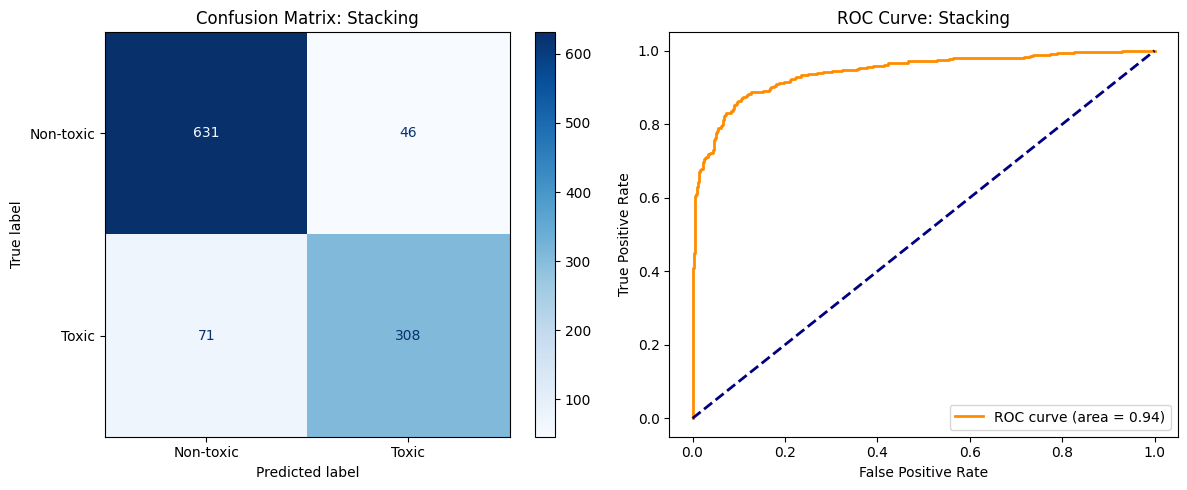

In [52]:
# 04 Confusion Matrix Plot and ROC Curve Plot
# Confusion matrix
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-toxic', 'Toxic'])
cm_display.plot(ax=ax[0], cmap='Blues', values_format='d')
ax[0].set_title(f'Confusion Matrix: {name}')
fpr, tpr, _ = roc_curve(y_test, y_prob)
#ROC
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax[1].plot([0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title(f'ROC Curve: {name}')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [51]:
# 04 Create Performance DataFrame
perf_df = pd.DataFrame(results).set_index("Model")

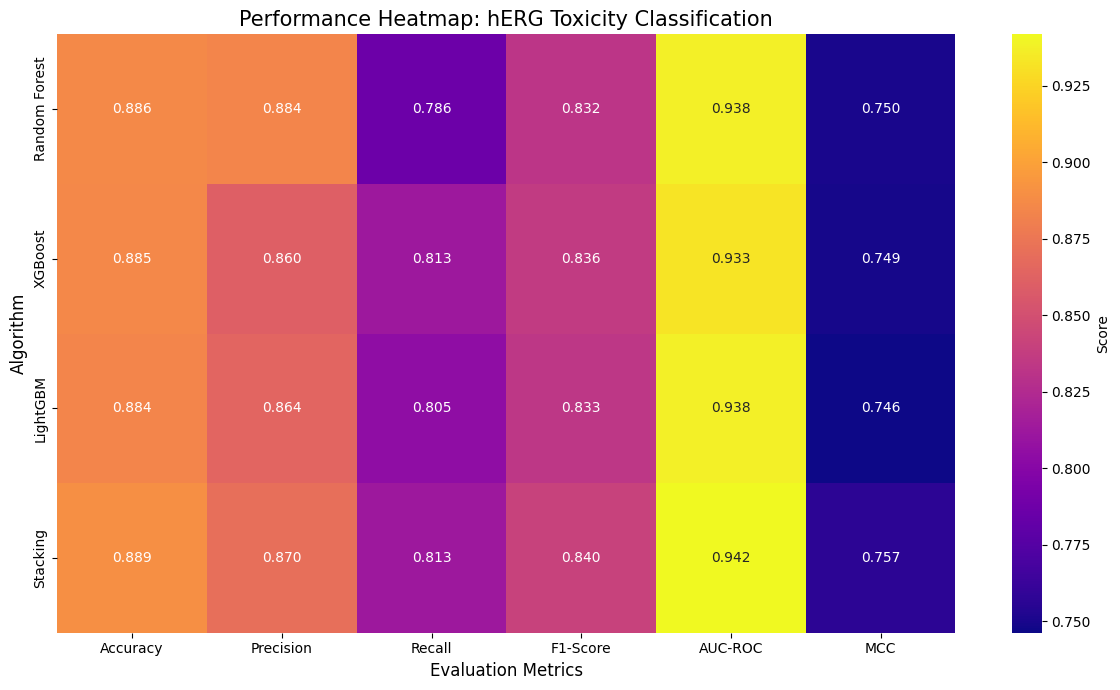

In [56]:
# 05 Generate the Performance Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(perf_df, annot=True, cmap='plasma', fmt=".3f", cbar_kws={'label': 'Score'})
plt.title('Performance Heatmap: hERG Toxicity Classification', fontsize=15)
plt.xlabel('Evaluation Metrics', fontsize=12)
plt.ylabel('Algorithm', fontsize=12)
plt.tight_layout()
plt.show()

In [54]:
# 06 # Export for your project report
perf_df.to_csv('/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Output/06_toxicity_performance_summary.csv')

## **Step 10: Model Persistence** 💾✨

This crucial final step focuses on saving the trained machine learning model to ensure its reusability and to facilitate future predictions without the need for retraining. Model persistence is essential for deploying predictive analytics solutions in real-world applications.

Specifically, we will perform the following operations:

*   **Serialization** ⚙️: The trained model will be serialized (e.g., using `pickle` or `joblib`) to a file.
*   **Storage** 🗄️: The serialized model will be stored in a designated directory, making it accessible for later retrieval.

This ensures that the developed hERG toxicity prediction model can be easily loaded and utilized for classifying new chemical compounds, thereby streamlining the drug discovery process.

In [57]:
# 01 Import Joblib
import joblib

In [ ]:
# 02 Saving The final (Stacking) Model
model_filename = '/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Model/hERG_toxicity_stacking_model.pkl'
joblib.dump(stacking_model, model_filename)

In [ ]:
# 03 Saving The Feature list also
feature_list = X.columns.tolist()
joblib.dump(feature_list, '/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Model/model_features.pkl')

## **Step 11: Model Interpretability** 💡🔍

This crucial step focuses on understanding how the trained machine learning models make their predictions. Model interpretability is vital in drug discovery for several reasons:

*   **Trust and Acceptance** ✅: Understanding the model's decision-making process builds trust among researchers and stakeholders.
*   **Drug Design Insights** 💊: Identifying which molecular features contribute most to hERG activity can provide valuable insights for designing new, safer compounds.
*   **Regulatory Compliance** 📜: Explaining model predictions is often necessary for regulatory submissions and risk assessment.

We will use techniques such as:

*   **Feature Importance** 📊: To identify the most influential molecular fingerprints (bits) that drive the model's classification.
*   **SHAP (SHapley Additive exPlanations)** 🤝: To explain individual predictions by showing the contribution of each feature to the output.

By elucidating the factors that influence the model's predictions, we can gain a deeper understanding of hERG channel inhibition and potentially uncover new structure-activity relationships.

In [60]:
# 01 Import SHAP
import shap

In [61]:
# 02 SHAP Explainer Setup
background_data = shap.kmeans(X_train, 10)

In [ ]:
# 03 Making Explainer
explainer = shap.KernelExplainer(model.predict_proba, background_data)

In [ ]:
# 04 Calculating SHAP Values (for top 50 molecules)
shap_values = explainer.shap_values(X_test.iloc[:50, :])

In [78]:
# 05 Verify dimensions
print(f"Shape of shap_values: {shap_values.shape}")
print(f"Shape of X_test subset: {X_test.iloc[:50, :].shape}")

Shape of shap_values: (50, 2048, 2)
Shape of X_test subset: (50, 2048)


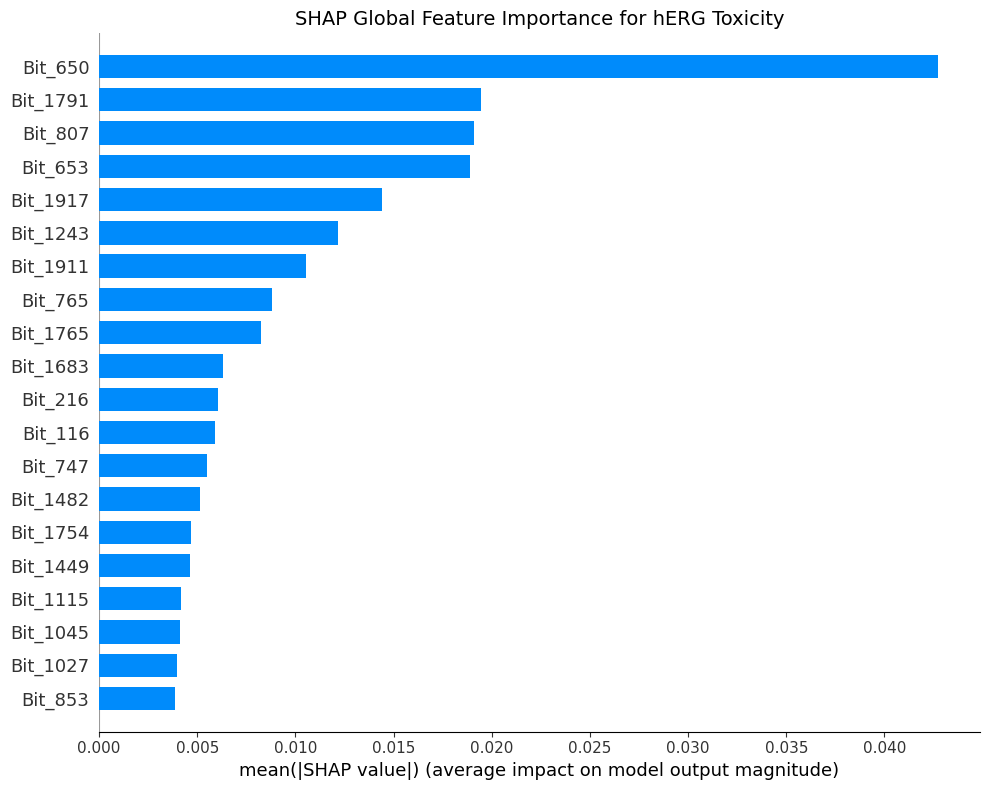

In [85]:
# 06 Generate Plot (Removed plt.figure to prevent blank canvas)
shap.summary_plot(
    current_shap_values,
    X_test.iloc[:50, :],
    plot_type="bar",
    feature_names=X_test.columns.tolist(),
    show=False,
    plot_size=(10, 8) # Set size directly inside SHAP
)

# 07. Final Touches
plt.title("SHAP Global Feature Importance for hERG Toxicity", fontsize=14)
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
plt.tight_layout()
plt.show()

## **Step 12: Decoding Molecular Fingerprint Bits** 🔑

This final section focuses on interpreting the molecular fingerprints, specifically decoding the bits that contribute most significantly to the model's predictions. By identifying the chemical substructures associated with these influential bits, we can gain valuable insights into the structural features that drive hERG channel inhibition. This interpretability is crucial for understanding the underlying mechanisms of cardiotoxicity and for guiding the rational design of safer drug candidates.



In [86]:
# 01 Importing needed libraries
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from IPython.display import display
from PIL import Image

In [87]:
# 02 Automated extraction of the most influential bits
mean_abs_shap = np.abs(current_shap_values).mean(axis=0)

In [88]:
# 03 Get indices of the top 10 bits
num_top_bits = 10
top_indices = np.argsort(mean_abs_shap)[-num_top_bits:][::-1]

In [89]:
# 04 Extract actual Bit IDs (e.g., 'Bit_650' -> 650)
top_bit_ids = [int(X_test.columns[i].split('_')[1]) for i in top_indices]

print(f"Top {num_top_bits} Toxicophore Bits identified: {top_bit_ids}")

Top 10 Toxicophore Bits identified: [650, 1791, 807, 653, 1917, 1243, 1911, 765, 1765, 1683]


In [ ]:
# 05 Automated Decoding Engine
def automated_morgan_decoder(bit_list, test_df, smiles_col='SMILES'):
    """
    Scans molecules to find and highlight specific Morgan fingerprint bits.
    """
    bit_images = []
    bit_legends = []
    found_bits = set()

    # Search through the first 1000 molecules for matching fragments
    for _, row in test_df.iterrows():
        if len(found_bits) == len(bit_list):
            break

        mol = Chem.MolFromSmiles(row[smiles_col])
        if mol is None: continue

        bit_info = {}
        # Ensure parameters match your training: Radius=2, nBits=2048
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048, bitInfo=bit_info)

        for bit_id in bit_list:
            if bit_id in bit_info and bit_id not in found_bits:
                # Generate high-res fragment visualization
                img = Draw.DrawMorganBit(mol, bit_id, bit_info)
                bit_images.append(img)
                bit_legends.append(f"Bit {bit_id}")
                found_bits.add(bit_id)

    return bit_images, bit_legends

# search_df pulls from your original SMILES using test indices
search_df = df_final.loc[X_test.index].head(1000)
images, legends = automated_morgan_decoder(top_bit_ids, search_df)

## **Step 13: Structural Alert Grid Visualization** 🖼️

This final visualization step aims to create a grid display of the molecular fragments corresponding to the most influential Morgan fingerprint bits. By visually inspecting these 'toxicophores' or key structural alerts, medicinal chemists can gain intuitive insights into the structural features that contribute to hERG channel inhibition. This visual aid is invaluable for guiding lead optimization efforts and designing compounds with improved safety profiles.


--- Automated Structural Alerts (Toxicophores) Identified ---


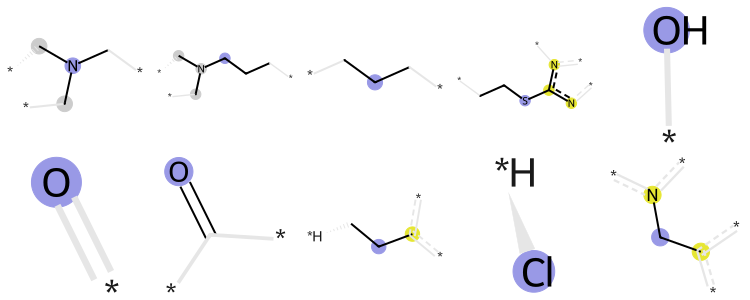

In [91]:
# 01 define the function
def create_alert_grid(imgs, labels, cols=5):
    """
    Compiles PIL images into a professional grid.
    """
    rows = (len(imgs) + cols - 1) // cols
    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols * w, rows * h), color='white')

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i % cols * w, i // cols * h))

    return grid

# Display and save the final reproducible result
if images:
    final_grid = create_alert_grid(images, legends, cols=5)
    final_grid.save("hERG_structural_alerts.png")
    print("--- Automated Structural Alerts (Toxicophores) Identified ---")
    display(final_grid)
else:
    print("No bits were decoded. Please verify your SMILES data.")

## **Step 14: Validation of Model with External Data** 🧪

This critical step involves assessing the predictive performance of the developed machine learning model against an independent, external dataset. Validating the model with data not used during training or internal testing is crucial for ensuring its robustness, generalizability, and real-world applicability. This external validation helps to confirm that the model can accurately predict hERG channel inhibition for novel compounds, thereby providing confidence in its utility for drug discovery.

This process will typically involve:

*   **Loading an External Dataset** 📥: Acquiring and loading a new set of compounds with known hERG bioactivity.
*   **Feature Engineering for External Data** 🧬: Applying the same feature engineering techniques (e.g., Morgan fingerprint calculation) to the external dataset to transform SMILES strings into numerical features.
*   **Prediction with Trained Model** 🚀: Using the previously trained (and saved) hERG toxicity prediction model to make predictions on the new, unseen data.
*   **Evaluation of External Predictions** 📈: Comparing the model's predictions with the actual bioactivity labels of the external dataset using relevant classification metrics (e.g., accuracy, precision, recall, F1-score, AUC-ROC, MCC) to gauge its performance on truly novel compounds.

In [93]:
# 01 Loading The external data set
df_external = pd.read_csv("/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/External_Dataset/Flaval_External_data.csv")
df_external

,SMILES
0,C1CC2=C(C=C(C=C2)O)OC1C3=CC4=C(C=C3)OCO4
1,COC1C(OC2=C(C1OC)C(=C(C3=C2C=CO3)OC)OC)C4=CC=C...
2,C1CC2=CC=CC=C2OC1C3=CC=CC=C3
3,C1C(C(OC2=CC=CC=C21)C3=CC=CC=C3)O
4,C1CC2=CC=CC=C2O[C@H]1C3=CC=CC=C3
...,...
87,COC1=CC(=CC2=C1CCC(O2)C3=CC=CC=C3)O
88,C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC=C(C=C3)O)O
89,COC1=CC(=CC2=C1OC(CC2O)C3=CC=CC=C3)CC=C
90,C1CC2=C(C=CC=C2OC1C3=CC=CC=C3)O


In [94]:
# 02 Loading The saved Model
loaded_model = joblib.load('/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Model/hERG_toxicity_stacking_model.pkl')

In [95]:
# 03 Loading the feature pkl
loaded_features = joblib.load('/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Model/model_features.pkl')

In [ ]:
# 04 Featurizing the external data set according to the model
external_fps_list = df_external['SMILES'].apply(morgan_fingerprints).tolist()
external_fp_df = pd.DataFrame(external_fps_list, columns=[f'Bit_{i}' for i in range(2048)])

In [99]:
# 05 Align columns with the features the model was trained on
X_external = external_fp_df[loaded_features]
X_external

,Bit_0,Bit_1,Bit_2,Bit_3,Bit_4,Bit_5,Bit_6,Bit_7,Bit_8,Bit_9,...,Bit_2038,Bit_2039,Bit_2040,Bit_2041,Bit_2042,Bit_2043,Bit_2044,Bit_2045,Bit_2046,Bit_2047
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
88,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
89,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
90,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# 06 Predicting Herg Toxicity using the model
y_external_pred = loaded_model.predict(X_external)
y_external_prob = loaded_model.predict_proba(X_external)[:, 1]

In [110]:
# 07 Observing the Prediction
print("Predicted Classes:")
display(y_external_pred)

Predicted Classes:


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0])

In [ ]:
# 08 Observing The Prediction (Probabilities)
print("Predicted Probabilities (Class 1 - Active):")
display(y_external_prob)

In [118]:
# 09 Curating the final result in a data frame
external_results = pd.DataFrame({
    'PubChem_CID': pubchem_cids,
    'SMILES': df_external['SMILES'],
    'Predicted_Class': y_external_pred,
    'Predicted_Probability': y_external_prob
})

In [119]:
# 10 Observation
external_results

,PubChem_CID,SMILES,Predicted_Class,Predicted_Probability
0,12052874,C1CC2=C(C=C(C=C2)O)OC1C3=CC4=C(C=C3)OCO4,0,0.230558
1,44257169,COC1C(OC2=C(C1OC)C(=C(C3=C2C=CO3)OC)OC)C4=CC=C...,0,0.257535
2,94156,C1CC2=CC=CC=C2OC1C3=CC=CC=C3,0,0.083221
3,3707243,C1C(C(OC2=CC=CC=C21)C3=CC=CC=C3)O,0,0.117926
4,1232440,C1CC2=CC=CC=C2O[C@H]1C3=CC=CC=C3,0,0.083221
...,...,...,...,...
87,342294,COC1=CC(=CC2=C1CCC(O2)C3=CC=CC=C3)O,0,0.234912
88,282014,C1C(C(OC2=CC(=CC(=C21)O)O)C3=CC=C(C=C3)O)O,0,0.131852
89,369608,COC1=CC(=CC2=C1OC(CC2O)C3=CC=CC=C3)CC=C,0,0.246303
90,13250353,C1CC2=C(C=CC=C2OC1C3=CC=CC=C3)O,0,0.283004


In [120]:
# 11 Fetching Compound PubChem IDs from SMILES using pubchempy
%%capture
!pip install pubchempy

In [121]:
# 12 Importing PubChemPy
import pubchempy as pcp

In [122]:
# 13 Fetching PubChem CIDs for the external compounds
pubchem_cids = []
for smiles in external_results['SMILES']:
    try:
        # Search for compounds by SMILES
        compounds = pcp.get_compounds(smiles, 'smiles')
        if compounds:
            # Take the CID of the first matching compound
            pubchem_cids.append(compounds[0].cid)
        else:
            pubchem_cids.append(None) # No match found
    except Exception as e:
        print(f"Error fetching CID for SMILES {smiles}: {e}")
        pubchem_cids.append(None)

external_results['PubChem_CID'] = pubchem_cids
external_results.head()

,PubChem_CID,SMILES,Predicted_Class,Predicted_Probability
0,12052874,C1CC2=C(C=C(C=C2)O)OC1C3=CC4=C(C=C3)OCO4,0,0.230558
1,44257169,COC1C(OC2=C(C1OC)C(=C(C3=C2C=CO3)OC)OC)C4=CC=C...,0,0.257535
2,94156,C1CC2=CC=CC=C2OC1C3=CC=CC=C3,0,0.083221
3,3707243,C1C(C(OC2=CC=CC=C21)C3=CC=CC=C3)O,0,0.117926
4,1232440,C1CC2=CC=CC=C2O[C@H]1C3=CC=CC=C3,0,0.083221


In [124]:
# 14 Export the result to csv
external_results.to_csv("/content/drive/MyDrive/01 Academic Projects/04 ML Toxicologigal Modeling (hERG)/Output/Predicted_Herg_result.csv")